Loading MNIST dataset...

Training Model 1: Sigmoid + Softmax
Epoch    0 | Train Acc: 0.0991 | Val Acc: 0.1032
Epoch  100 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  200 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  300 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  400 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  500 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  600 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  700 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  800 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  900 | Train Acc: 0.1125 | Val Acc: 0.1084

Training Model 2: ReLU + Softmax
Epoch    0 | Train Acc: 0.1126 | Val Acc: 0.1084
Epoch  100 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  200 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  300 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  400 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  500 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  600 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  700 | Train Acc: 0.1125 | Val Acc: 0.1084
Epoch  800 | Train Acc

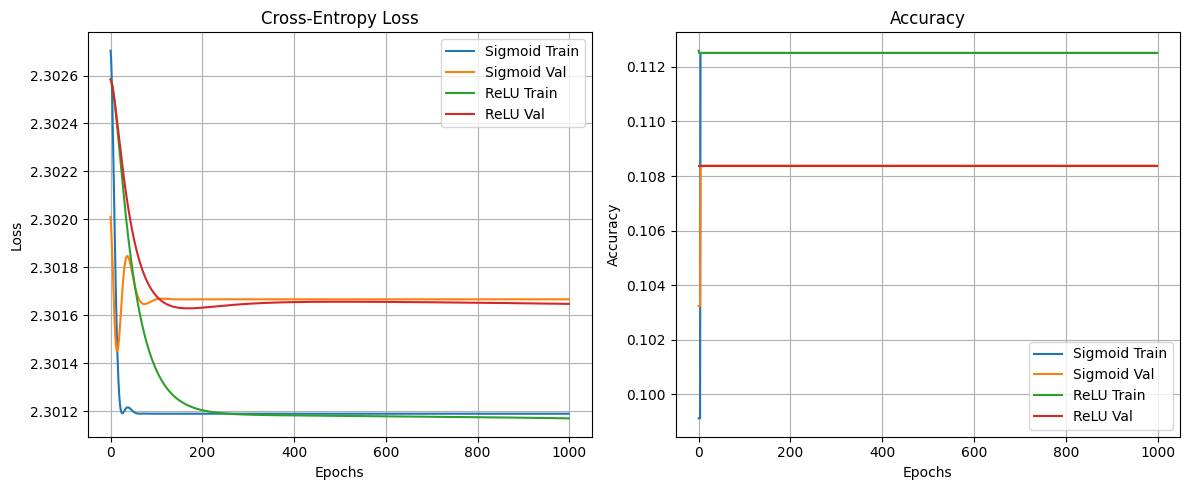

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =========================================================
# 1. Load MNIST Dataset
# =========================================================

print("Loading MNIST dataset...")
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

X = X / 255.0
y = y.astype(int)

# Manual One-Hot Encoding (Version Safe)
num_classes = 10
y_oh = np.eye(num_classes)[y]

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_oh, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# =========================================================
# 2. Activation Functions
# =========================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# =========================================================
# 3. Loss Function
# =========================================================

def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))

# =========================================================
# 4. Deep ANN Class (Backpropagation From Scratch)
# =========================================================

class DeepANN:
    def __init__(self, layer_sizes, activation="sigmoid", lr=0.01, momentum=0.9):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.lr = lr
        self.momentum = momentum

        self.weights = []
        self.biases = []
        self.vel_w = []
        self.vel_b = []

        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01)
            self.biases.append(np.zeros((1, layer_sizes[i+1])))
            self.vel_w.append(np.zeros_like(self.weights[i]))
            self.vel_b.append(np.zeros_like(self.biases[i]))

        self.train_loss, self.val_loss = [], []
        self.train_acc, self.val_acc = [], []

    def forward(self, X):
        a = X
        activations = [X]
        zs = []

        for i in range(len(self.weights) - 1):
            z = a @ self.weights[i] + self.biases[i]
            zs.append(z)

            a = sigmoid(z) if self.activation == "sigmoid" else relu(z)
            activations.append(a)

        z = a @ self.weights[-1] + self.biases[-1]
        zs.append(z)
        a = softmax(z)
        activations.append(a)

        return activations, zs

    def backward(self, activations, zs, y_true):
        grads_w, grads_b = [], []
        delta = activations[-1] - y_true

        for i in reversed(range(len(self.weights))):
            dw = activations[i].T @ delta / y_true.shape[0]
            db = np.mean(delta, axis=0, keepdims=True)
            grads_w.insert(0, dw)
            grads_b.insert(0, db)

            if i > 0:
                if self.activation == "sigmoid":
                    delta = (delta @ self.weights[i].T) * sigmoid_derivative(activations[i])
                else:
                    delta = (delta @ self.weights[i].T) * relu_derivative(zs[i-1])

        return grads_w, grads_b

    def update(self, grads_w, grads_b):
        for i in range(len(self.weights)):
            self.vel_w[i] = self.momentum * self.vel_w[i] - self.lr * grads_w[i]
            self.vel_b[i] = self.momentum * self.vel_b[i] - self.lr * grads_b[i]
            self.weights[i] += self.vel_w[i]
            self.biases[i] += self.vel_b[i]

    def evaluate(self, X, y):
        y_pred = self.forward(X)[0][-1]
        return accuracy_score(np.argmax(y, axis=1), np.argmax(y_pred, axis=1))

    def train(self, X, y, X_val, y_val, epochs=1000):
        for epoch in range(epochs):
            activations, zs = self.forward(X)
            grads_w, grads_b = self.backward(activations, zs, y)
            self.update(grads_w, grads_b)

            train_pred = activations[-1]
            val_pred = self.forward(X_val)[0][-1]

            self.train_loss.append(cross_entropy(y, train_pred))
            self.val_loss.append(cross_entropy(y_val, val_pred))
            self.train_acc.append(self.evaluate(X, y))
            self.val_acc.append(self.evaluate(X_val, y_val))

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | "
                      f"Train Acc: {self.train_acc[-1]:.4f} | "
                      f"Val Acc: {self.val_acc[-1]:.4f}")

# =========================================================
# 5. Hyperparameters
# =========================================================

hidden_layers = [128, 64, 32]
epochs = 1000
lr = 0.01
momentum = 0.9

# =========================================================
# 6. Train Model 1: Sigmoid
# =========================================================

print("\nTraining Model 1: Sigmoid + Softmax")
model_sigmoid = DeepANN(
    layer_sizes=[784] + hidden_layers + [10],
    activation="sigmoid",
    lr=lr,
    momentum=momentum
)
model_sigmoid.train(X_train, y_train, X_val, y_val, epochs)

# =========================================================
# 7. Train Model 2: ReLU
# =========================================================

print("\nTraining Model 2: ReLU + Softmax")
model_relu = DeepANN(
    layer_sizes=[784] + hidden_layers + [10],
    activation="relu",
    lr=lr,
    momentum=momentum
)
model_relu.train(X_train, y_train, X_val, y_val, epochs)

# =========================================================
# 8. Test Performance
# =========================================================

print("\nFinal Test Accuracy")
print("Sigmoid Model:", model_sigmoid.evaluate(X_test, y_test))
print("ReLU Model   :", model_relu.evaluate(X_test, y_test))

# =========================================================
# 9. Loss & Accuracy Plots
# =========================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_sigmoid.train_loss, label="Sigmoid Train")
plt.plot(model_sigmoid.val_loss, label="Sigmoid Val")
plt.plot(model_relu.train_loss, label="ReLU Train")
plt.plot(model_relu.val_loss, label="ReLU Val")
plt.title("Cross-Entropy Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(model_sigmoid.train_acc, label="Sigmoid Train")
plt.plot(model_sigmoid.val_acc, label="Sigmoid Val")
plt.plot(model_relu.train_acc, label="ReLU Train")
plt.plot(model_relu.val_acc, label="ReLU Val")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()